In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pylab as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Задание 3. 

Возьмем датасет про доставку еды: в нашем датасете есть базовая информация о доставке (на каком транспортном средстве ехал курьер, было это утром, днем или вечером, в какую погоду и так далее). Проверьте, нет ли в датасете пропущенных ячеек: scikit-learn не умеет работать с отсутствующими данными, их нужно убрать или каким-либо образом заполнить. Используйте One Hot Encoding для категориальных признаков. Обучите линейную регрессию для предсказания времени доставки и посчитайте, на сколько минут в среднем ошибается ваша модель. я?

In [2]:
fooddelivery = pd.read_csv('Food_Delivery_Times.csv')
fooddelivery.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [3]:
headers = ['Weather','Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Courier_Experience_yrs']
for i in headers:
    unique = fooddelivery[i].unique()
    print(unique)


['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy' nan]
['Low' 'Medium' 'High' nan]
['Afternoon' 'Evening' 'Night' 'Morning' nan]
['Scooter' 'Bike' 'Car']
[ 1.  2.  5.  9.  6.  4.  7. nan  3.  8.  0.]


In [4]:
# Проверьте, нет ли в датасете пропущенных ячеек: 
# scikit-learn не умеет работать с отсутствующими данными, их нужно убрать или каким-либо образом заполнить
fooddelivery.isnull().sum()
#не указано 30 значений в погоде, уровне загрузки, времени и опыте курьера

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [5]:
fooddelivery =  fooddelivery.dropna()
fooddelivery

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [6]:
fooddelivery = fooddelivery.drop('Order_ID', axis = 1)
fooddelivery = fooddelivery.drop('Preparation_Time_min', axis = 1)

fooddelivery = pd.get_dummies(fooddelivery, drop_first=True)
fooddelivery

,Distance_km,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,1.0,43,False,False,False,True,True,False,False,False,False,False,True
1,16.42,2.0,84,False,False,False,False,False,True,True,False,False,False,False
2,9.52,1.0,59,True,False,False,False,True,False,False,False,True,False,True
3,7.44,1.0,37,False,True,False,False,False,True,False,False,False,False,True
4,19.03,5.0,68,False,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.50,3.0,54,False,False,False,False,False,False,True,False,False,True,False
996,16.28,9.0,71,False,True,False,False,True,False,False,True,False,False,True
997,15.62,2.0,81,False,False,True,False,False,False,True,False,False,False,True
998,14.17,0.0,55,False,False,False,False,True,False,False,False,False,False,False


Distance_km


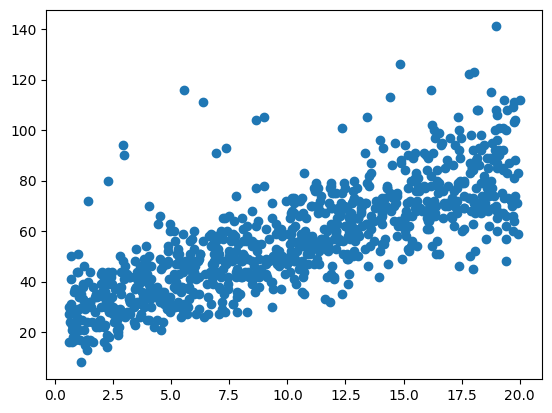

Courier_Experience_yrs


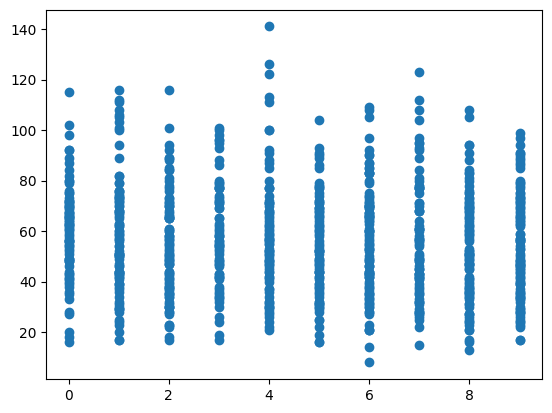

Weather_Foggy


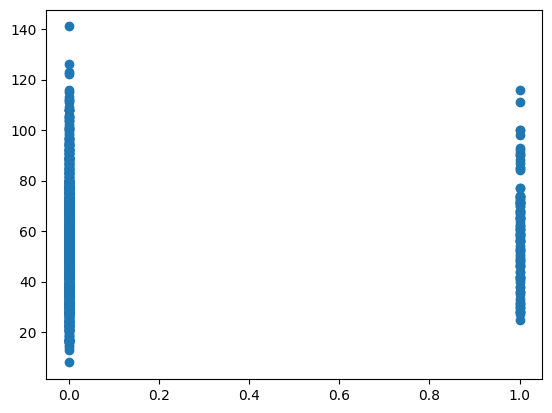

Weather_Rainy


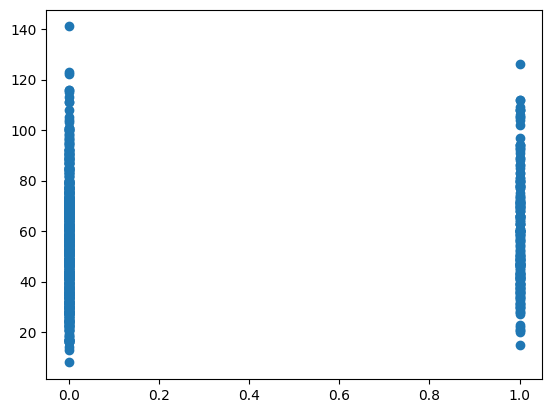

Weather_Snowy


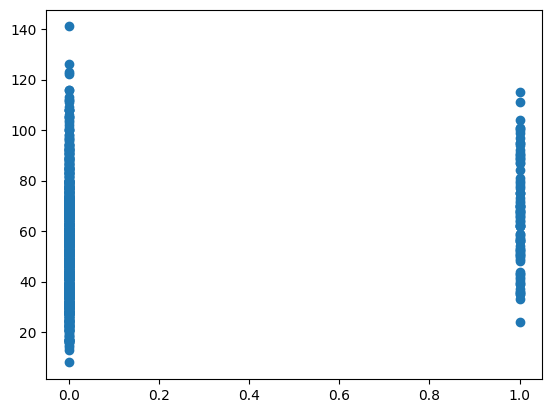

Weather_Windy


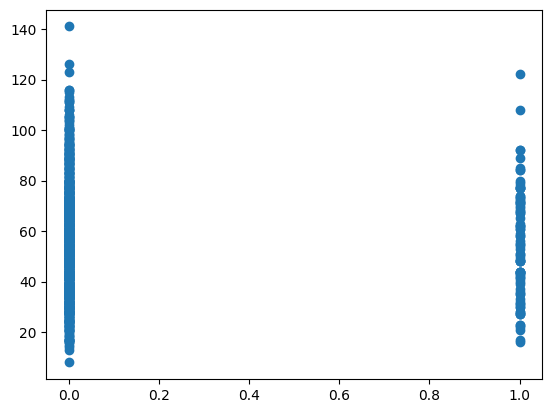

Traffic_Level_Low


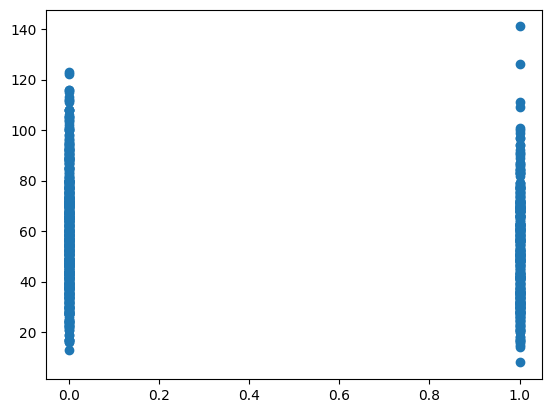

Traffic_Level_Medium


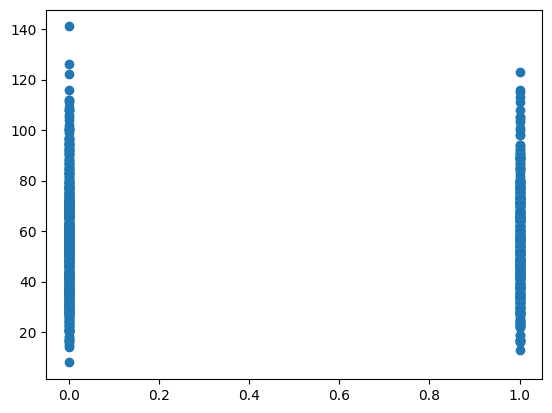

Time_of_Day_Evening


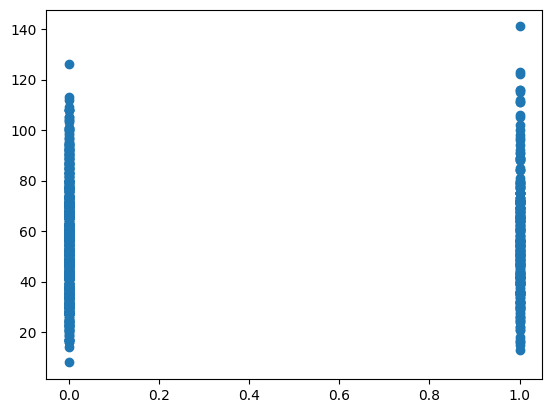

Time_of_Day_Morning


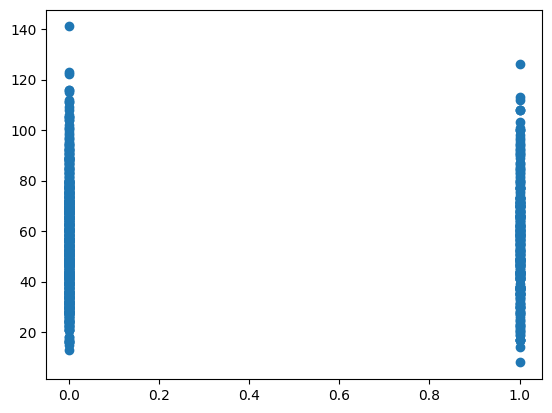

Time_of_Day_Night


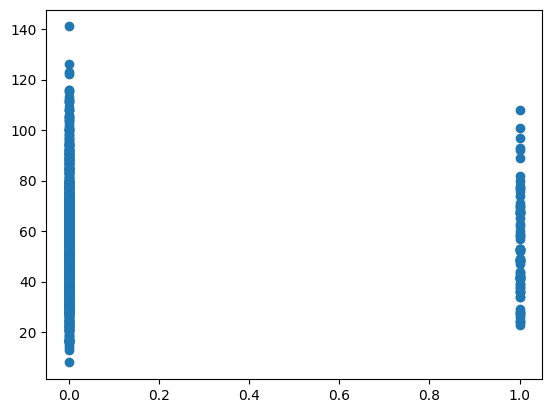

Vehicle_Type_Car


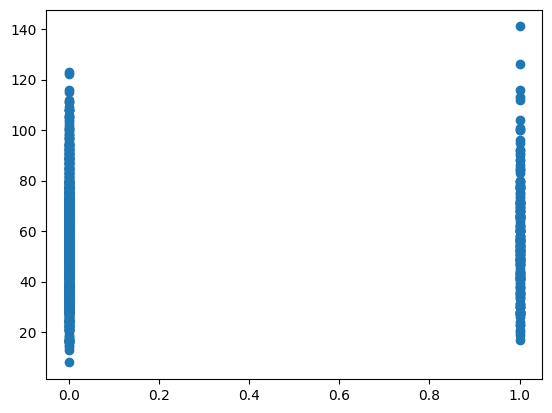

Vehicle_Type_Scooter


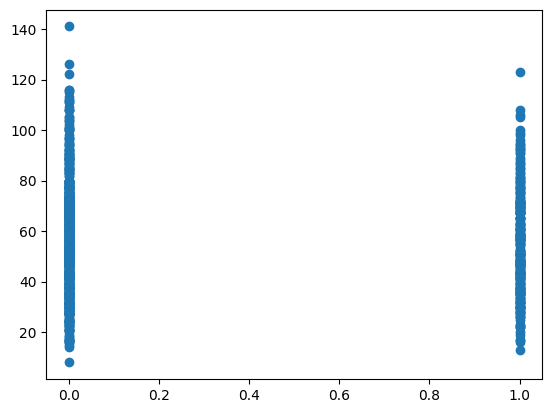

In [7]:
for c in fooddelivery.columns:
    if c != 'Delivery_Time_min':
        print(c)
        plt.scatter(fooddelivery[c], fooddelivery['Delivery_Time_min'])
        plt.show()

In [8]:
y = fooddelivery['Delivery_Time_min']
X = fooddelivery.drop('Delivery_Time_min', axis=1)

In [9]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)



model = LinearRegression()
model.fit(Xtrain, ytrain) # обучение модели
pred_train = model.predict(Xtrain)
pred_test = model.predict(Xtest)

In [10]:
print(mean_squared_error(pred_test, ytest) ** 0.5, mean_squared_error(pred_train, ytrain) ** 0.5)

11.307120211248936 12.312590636457413


In [11]:
coef = model.coef_.tolist() # веса при признаках
intercept = model.intercept_# свободный коэффициент (w0)
a = list(zip(X.columns, coef))
print(coef, intercept)
a

[2.960514413511092, -0.6323194962737106, 7.942524620385394, 4.2374339968158985, 9.592398670819035, 1.175554199900298, -12.04680308151503, -7.376782415120383, 2.089183235451249, -0.0076976273085363894, -1.0690997754908782, 0.9157018751938942, -0.5041181396730822] 34.27826464984592


[('Distance_km', 2.960514413511092),
 ('Courier_Experience_yrs', -0.6323194962737106),
 ('Weather_Foggy', 7.942524620385394),
 ('Weather_Rainy', 4.2374339968158985),
 ('Weather_Snowy', 9.592398670819035),
 ('Weather_Windy', 1.175554199900298),
 ('Traffic_Level_Low', -12.04680308151503),
 ('Traffic_Level_Medium', -7.376782415120383),
 ('Time_of_Day_Evening', 2.089183235451249),
 ('Time_of_Day_Morning', -0.0076976273085363894),
 ('Time_of_Day_Night', -1.0690997754908782),
 ('Vehicle_Type_Car', 0.9157018751938942),
 ('Vehicle_Type_Scooter', -0.5041181396730822)]